In [1]:
#load the dataset
import pandas as pd

df = pd.read_csv("../data/blood_demand_data.csv")

df.head()

,date,O+,A+,B+,AB+,O-,A-,B-,AB-
0,2023-01-01,10,9,2,1,0,0,0,0
1,2023-01-02,20,18,5,2,1,1,0,0
2,2023-01-03,19,17,5,2,1,1,0,0
3,2023-01-04,22,20,6,2,1,1,0,0
4,2023-01-05,22,20,6,2,1,1,0,0


In [7]:
#train the model for all blood groups
import sys
import os

# Add the parent directory to Python path
sys.path.append(os.path.abspath(".."))

from prophet import Prophet
from model.holiday_data import get_ethiopian_holidays
from model.stock_data import get_current_stock

current_stock = get_current_stock()

blood_types = ["O+","A+","B+","AB+", "O-","A-", "B-","AB-"]

predictions = {}
predictions_uncertainty = {}

# Load Ethiopian holidays
ethiopian_holidays = get_ethiopian_holidays()

for bt in blood_types:

    df_prophet = df[['date', bt]].rename(columns={
        "date":"ds",
        bt:"y"
    })

    # Create Prophet model with holidays
    model = Prophet(
        holidays=ethiopian_holidays,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    model.fit(df_prophet)

    # Save the model
    import pickle
    with open(f"../model_files/prophet_{bt}_model.pkl", "wb") as f:
        pickle.dump(model, f)

    # suppose df_prophet ends in 2024-12-31
    future_dates = pd.date_range(start="2026-03-13", periods=30)
    future = pd.DataFrame({"ds": future_dates})
    # future = model.make_future_dataframe(periods=30)

    forecast = model.predict(future)

    predictions[bt] = forecast[['ds','yhat']].tail(30)
    predictions_uncertainty[bt] = forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

predictions



# blood types to forecast
# blood_types = ["O+","A+","B+","AB+", "O-", "A-", "B-", "AB-"]

output = []

# Convert holiday dates to string for easy matching
holiday_dates = ethiopian_holidays['ds'].dt.strftime('%Y-%m-%d').tolist()
holiday_names = dict(zip(
    ethiopian_holidays['ds'].dt.strftime('%Y-%m-%d'),
    ethiopian_holidays['holiday']
))

days_to_output = 30

for i in range(days_to_output):
    record = {"date": predictions["O+"].iloc[i]["ds"].strftime("%Y-%m-%d")}
    
    # Check if date is a holiday
    if record["date"] in holiday_dates:
        record["holiday"] = holiday_names[record["date"]]
    else:
        record["holiday"] = None
    
    # Add predicted units and check stock
    shortage_alerts = []
    
    for bt in blood_types:
        predicted_units = int(predictions[bt].iloc[i]["yhat"].round())
        record[bt] = predicted_units
        
        # Check if predicted demand exceeds current stock
        stock = current_stock.get(bt, 0)
        if predicted_units > stock:
            shortage_alerts.append(f"{bt} shortage: predicted {predicted_units}, stock {stock}")
    
    # Add alerts to record
    record["alerts"] = shortage_alerts if shortage_alerts else None
    
    output.append(record)

# Example output
output[0:5]  # show first 5 days

08:05:20 - cmdstanpy - INFO - Chain [1] start processing
08:05:20 - cmdstanpy - INFO - Chain [1] done processing
08:05:20 - cmdstanpy - INFO - Chain [1] start processing
08:05:20 - cmdstanpy - INFO - Chain [1] done processing
08:05:20 - cmdstanpy - INFO - Chain [1] start processing
08:05:20 - cmdstanpy - INFO - Chain [1] done processing
08:05:21 - cmdstanpy - INFO - Chain [1] start processing
08:05:21 - cmdstanpy - INFO - Chain [1] done processing
08:05:21 - cmdstanpy - INFO - Chain [1] start processing
08:05:21 - cmdstanpy - INFO - Chain [1] done processing
08:05:21 - cmdstanpy - INFO - Chain [1] start processing
08:05:22 - cmdstanpy - INFO - Chain [1] done processing


[{'date': '2026-03-13',
  'holiday': None,
  'O+': 17,
  'A+': 16,
  'B+': 4,
  'AB+': 1,
  'O-': 0,
  'A-': 0,
  'B-': 0,
  'AB-': 0,
  'alerts': ['O+ shortage: predicted 17, stock 2']},
 {'date': '2026-03-14',
  'holiday': None,
  'O+': 14,
  'A+': 13,
  'B+': 3,
  'AB+': 1,
  'O-': 0,
  'A-': 0,
  'B-': 0,
  'AB-': 0,
  'alerts': ['O+ shortage: predicted 14, stock 2']},
 {'date': '2026-03-15',
  'holiday': None,
  'O+': 14,
  'A+': 12,
  'B+': 3,
  'AB+': 1,
  'O-': 0,
  'A-': 0,
  'B-': 0,
  'AB-': 0,
  'alerts': ['O+ shortage: predicted 14, stock 2']},
 {'date': '2026-03-16',
  'holiday': None,
  'O+': 17,
  'A+': 16,
  'B+': 4,
  'AB+': 1,
  'O-': 0,
  'A-': 0,
  'B-': 0,
  'AB-': 0,
  'alerts': ['O+ shortage: predicted 17, stock 2']},
 {'date': '2026-03-17',
  'holiday': None,
  'O+': 16,
  'A+': 15,
  'B+': 4,
  'AB+': 1,
  'O-': 0,
  'A-': 0,
  'B-': 0,
  'AB-': 0,
  'alerts': ['O+ shortage: predicted 16, stock 2']}]

In [3]:
# #forecast future blood demand with uncertainty
# predictions_uncertainty

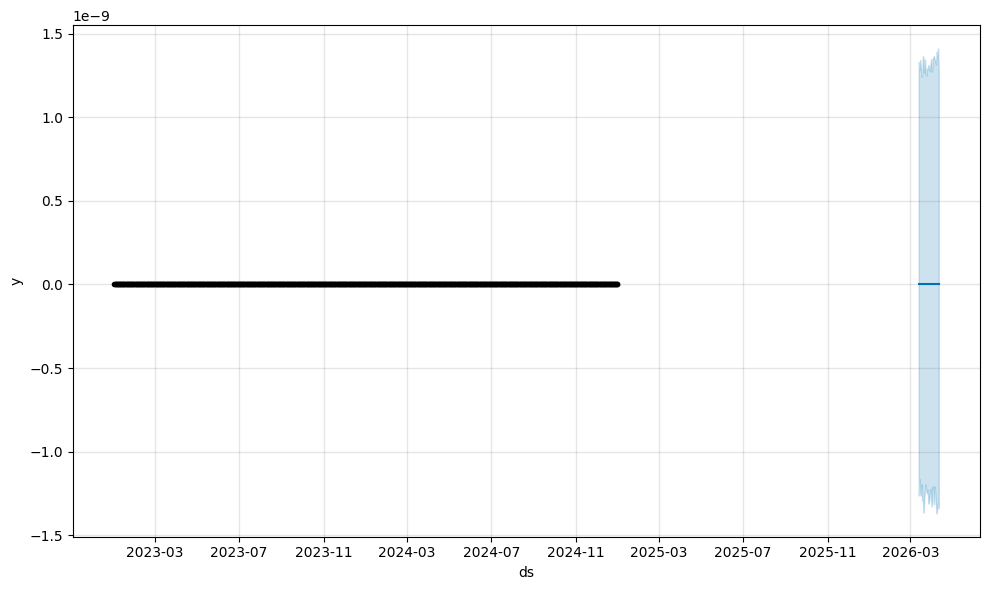

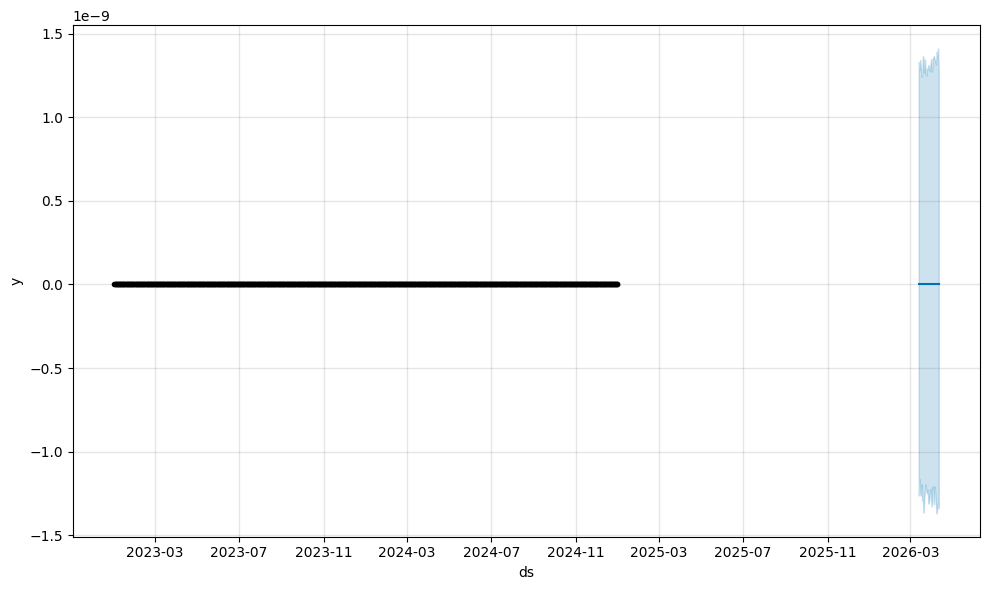

In [4]:
model.plot(forecast)

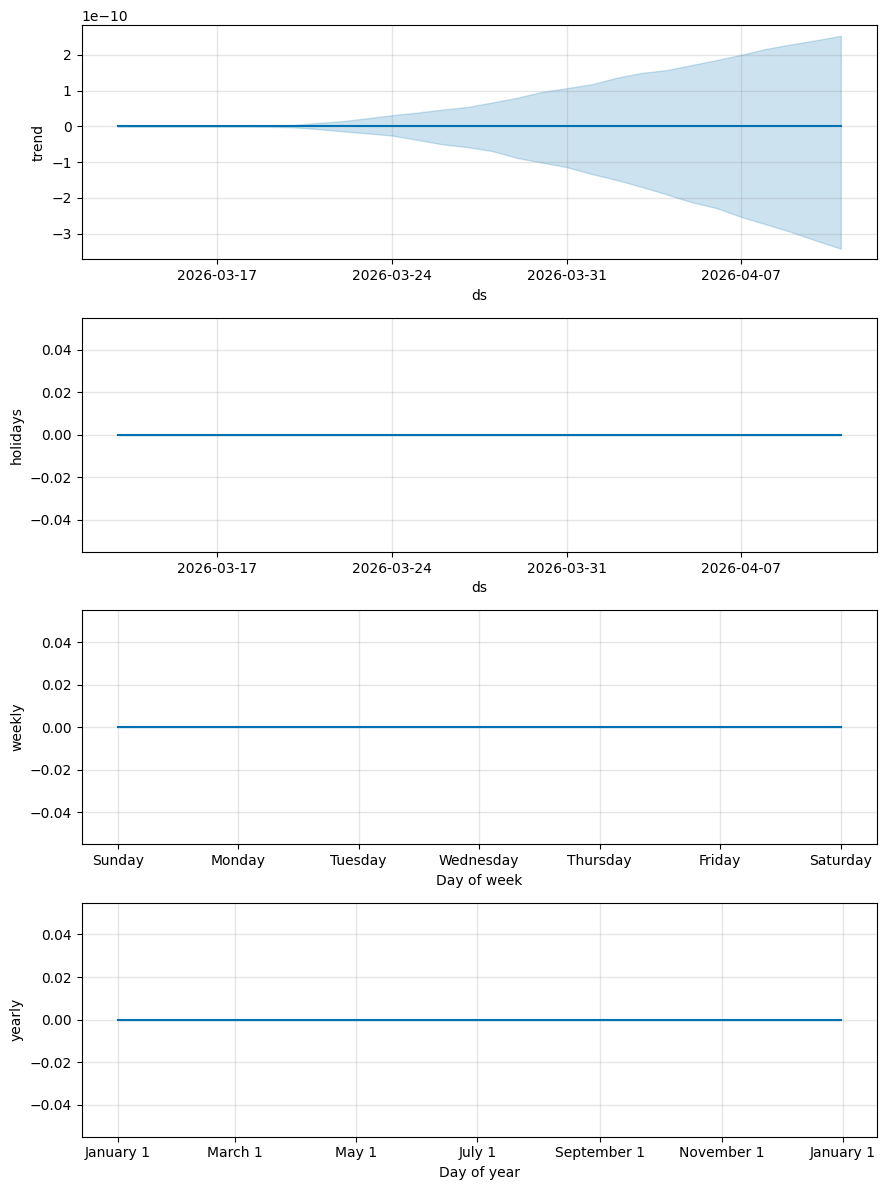

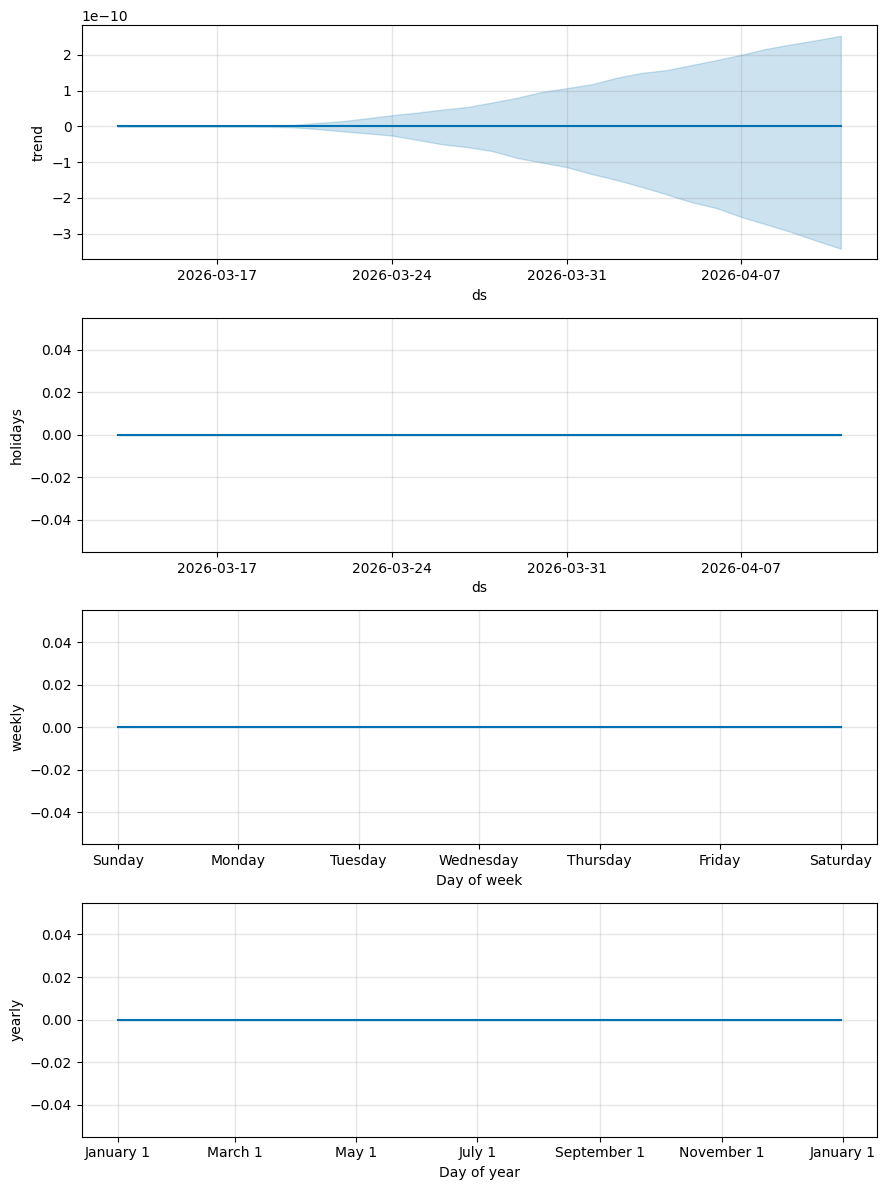

In [5]:
#This shows the patterns the model learned: weekly pattern, yearly trend, seasonal changes
model.plot_components(forecast)

In [6]:
forecast[['ds','yhat']].to_csv("../data/predicted_demand.csv", index=False)